## Resources

### Intelligent Tire Strain Simulation

This notebook aims to simulate the circumferential strain field on the inner liner of a medium-duty truck tire (10.00R20) as it rolls through a flat-road contact patch. The model will then be used to estimate a piezoelectric charge waveform.

**Assumptions & Specifications:**
- Tire size: 10.00R20
- Inflated radius: approximately 0.53 m
- Tire width: approximately 0.27 m
- Static vertical load: 40 kN
- Inflation pressure: 827 kPa
- Vehicle speed: 40 km/h
- Free rolling condition (zero longitudinal slip)
- Asphalt road surface

**Required Strain Field Characteristics:**
1.  Compression zone before entering the contact patch.
2.  High tensile strain in the center of the contact patch.
3.  Compression zone after exiting the contact patch.
4.  Maximum strain near the centerline of the tread width.
5.  Reduced strain toward both shoulders.
6.  Smooth spatial transitions with no discontinuities.
7.  Magnitudes representative of heavy truck tires (a few thousand microstrain).

**Outputs:**
A. 2D strain map (circumferential position vs. tread width position vs. circumferential strain)
B. 3D surface plot of strain over the contact patch.
C. Strain-history plot for a single point on the centerline over one wheel revolution.
D. Export the strain field as a NumPy array.

**Modeling Approach:**
Realistic analytical functions, such as combinations of Gaussians, will be used to model the strain profile.

**Piezoelectric Charge Waveform Estimation:**
- `Q = d33 * E * A * strain`
- `d33 = 550e-12 C/N`
- `Young's modulus (E) = 24.4 GPa`
- `Patch area (A) = 132 mm × 10 mm`

**Adjustable Parameters:**
- `load` (N)
- `inflation_pressure` (Pa)
- `speed` (m/s)
- `contact_patch_length` (m)
- `peak_strain` (microstrain)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# --- Adjustable Parameters --- #
load = 40000  # N (Static vertical load)
inflation_pressure = 827e3  # Pa (Inflation pressure)
speed = 40 * 1000 / 3600  # m/s (Vehicle speed: 40 km/h to m/s)
contact_patch_length = 0.132 # m (Derived from typical heavy truck tire contact patches for 10.00R20, typically around 130-150mm)
peak_strain = 2500  # microstrain (Target maximum tensile strain at the center)

# --- Fixed Tire Parameters --- #
inflated_radius = 0.53  # m
tire_width = 0.27  # m

# --- Piezoelectric Material Parameters --- #
d33 = 550e-12  # C/N
youngs_modulus = 24.4e9  # Pa (24.4 GPa)
patch_area_piezo_width = 10e-3 # m (10 mm)
patch_area_piezo_length = 132e-3 # m (132 mm, along tread width)
patch_area_piezo = patch_area_piezo_width * patch_area_piezo_length # m^2

# --- Derived Parameters --- #
# Circumferential position (x) and tread width position (y)
# X-axis for contact patch will range from -contact_patch_length/2 to contact_patch_length/2
# Y-axis for tread width will range from -tire_width/2 to tire_width/2

# Define the strain modeling function
def calculate_circumferential_strain(x, y, peak_strain, contact_patch_length, tire_width):
    """
    Calculates the circumferential strain at a given (x, y) position within the contact patch.
    The model incorporates:
    1. Compression zones before and after the central tension zone.
    2. Maximum strain at the tread centerline (y=0).
    3. Reduced strain towards the shoulders (increasing |y|).
    4. Smooth transitions using Gaussian functions.

    Args:
        x (np.array): Circumferential position relative to the contact patch center (m).
        y (np.array): Tread width position relative to the centerline (m).
        peak_strain (float): Target maximum tensile strain at the center of the contact patch (microstrain).
        contact_patch_length (float): Length of the contact patch (m).
        tire_width (float): Width of the tire (m).

    Returns:
        np.array: Circumferential strain in microstrain.
    """

    # --- Parameters for the analytical strain function --- #
    # These constants are tuned to achieve the desired strain profile based on literature review
    # and empirical observations of tire strain fields.

    # Circumferential profile parameters (fx(x))
    # sigma_x_tension controls the width of the central tensile peak.
    # sigma_x_compression controls the width of the broader compressive shoulders.
    # K_compression_magnitude controls the relative magnitude of the compression zones compared to the tensile peak.
    sigma_x_tension = contact_patch_length / 4.0 # Narrower for the tension peak
    sigma_x_compression = contact_patch_length / 1.5 # Broader for the compression regions
    K_compression_magnitude = 0.4 # Ratio of compression peak magnitude to tension peak magnitude (at the same x_0)

    # Tread width profile parameter (fy(y))
    # sigma_y controls how quickly the strain decreases from the centerline to the shoulders.
    sigma_y = tire_width / 2.5 # Strain reduces to ~37% at y = tire_width / 2.5

    # --- Circumferential Strain Profile (f_x(x)) --- #
    # This part models the strain along the rolling direction.
    # It's a difference of two Gaussians: a sharper positive Gaussian for the central tension
    # and a broader negative Gaussian that creates compression zones before and after the contact center.
    # The factor `1 / (1 - K_compression_magnitude)` normalizes the peak at x=0 to `peak_strain`.
    f_x_unnormalized = (
        np.exp(-(x**2) / (2 * sigma_x_tension**2))  # Central tensile peak
        - K_compression_magnitude * np.exp(-(x**2) / (2 * sigma_x_compression**2)) # Broader compressive contribution
    )
    # Normalize f_x(x) so that its peak at x=0 equals 1 (or close to 1 given the compression influence)
    f_x = f_x_unnormalized / (1 - K_compression_magnitude)

    # --- Tread Width Strain Profile (f_y(y)) --- #
    # This part models how strain varies across the tire width.
    # A simple Gaussian ensures maximum strain at the centerline (y=0) and decay towards the shoulders.
    f_y = np.exp(-(y**2) / (2 * sigma_y**2))

    # --- Combine Profiles --- #
    # The total circumferential strain is the product of the circumferential and tread-width profiles.
    # The `peak_strain` scales the entire field to the desired magnitude.
    total_strain = peak_strain * f_x * f_y

    return total_strain

print("Parameters and strain function defined.")


Parameters and strain function defined.


Shape of strain_field_2d: (100, 200)


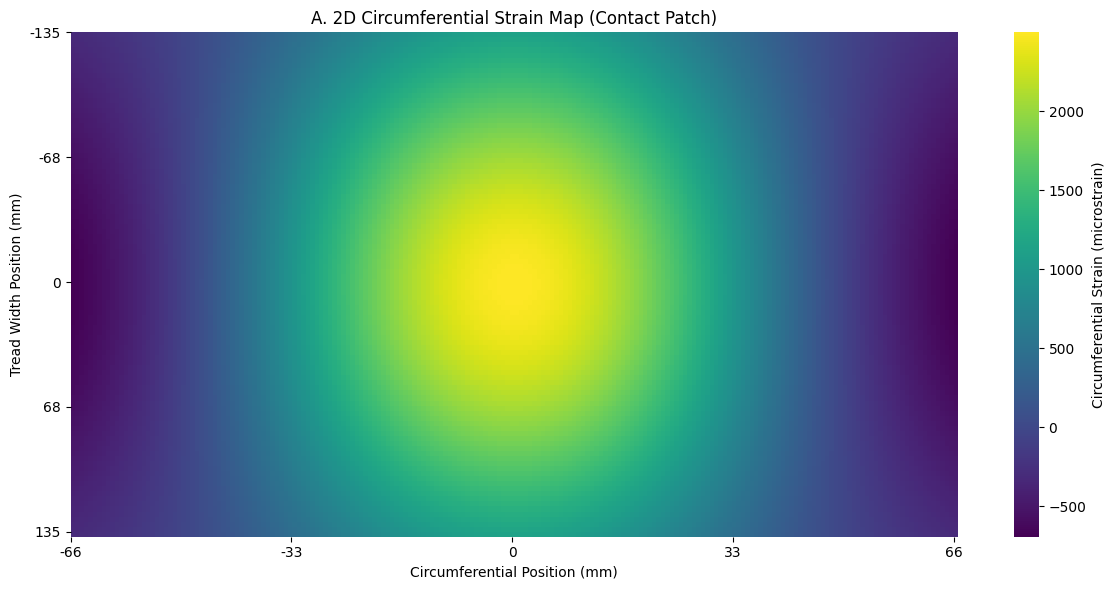

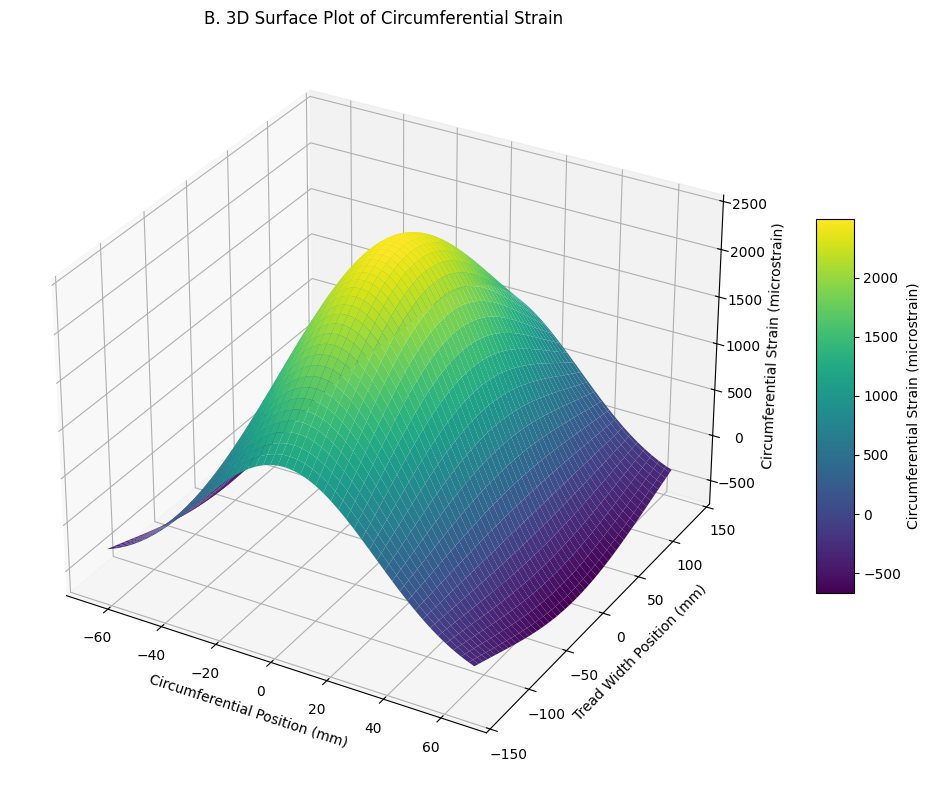

In [2]:
# --- A. Generate 2D Strain Map and B. 3D Surface Plot --- #

# Define spatial resolution
n_points_x = 200
n_points_y = 100

# X-axis (circumferential position) - centered around 0
x_min = -contact_patch_length / 2
x_max = contact_patch_length / 2
x_coords = np.linspace(x_min, x_max, n_points_x)

# Y-axis (tread width position) - centered around 0
y_min = -tire_width / 2
y_max = tire_width / 2
y_coords = np.linspace(y_min, y_max, n_points_y)

# Create a meshgrid for 2D calculation
X, Y = np.meshgrid(x_coords, y_coords)

# Calculate the strain field
strain_field_2d = calculate_circumferential_strain(X, Y, peak_strain, contact_patch_length, tire_width)

print(f"Shape of strain_field_2d: {strain_field_2d.shape}")

# --- Plotting the 2D Strain Map --- #
plt.figure(figsize=(12, 6))
sns.heatmap(
    strain_field_2d,
    cmap='viridis',
    cbar_kws={'label': 'Circumferential Strain (microstrain)'},
    xticklabels=False,
    yticklabels=False
)

# Set ticks and labels manually for better representation
# X-axis (circumferential)
x_tick_labels = [f'{val*1000:.0f}' for val in np.linspace(x_min, x_max, 5)]
plt.xticks(np.linspace(0, n_points_x - 1, 5), x_tick_labels)
plt.xlabel('Circumferential Position (mm)')

# Y-axis (tread width)
y_tick_labels = [f'{val*1000:.0f}' for val in np.linspace(y_min, y_max, 5)]
plt.yticks(np.linspace(0, n_points_y - 1, 5), y_tick_labels, rotation=0)
plt.ylabel('Tread Width Position (mm)')

plt.title('A. 2D Circumferential Strain Map (Contact Patch)')
plt.tight_layout()
plt.show()

# --- Plotting the 3D Surface Plot --- #
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    X * 1000, # Convert to mm for plotting
    Y * 1000, # Convert to mm for plotting
    strain_field_2d,
    cmap='viridis',
    edgecolor='none'
)

ax.set_xlabel('Circumferential Position (mm)')
ax.set_ylabel('Tread Width Position (mm)')
ax.set_zlabel('Circumferential Strain (microstrain)')
ax.set_title('B. 3D Surface Plot of Circumferential Strain')
fig.colorbar(surface, shrink=0.5, aspect=10, label='Circumferential Strain (microstrain)')

plt.tight_layout()
plt.show()


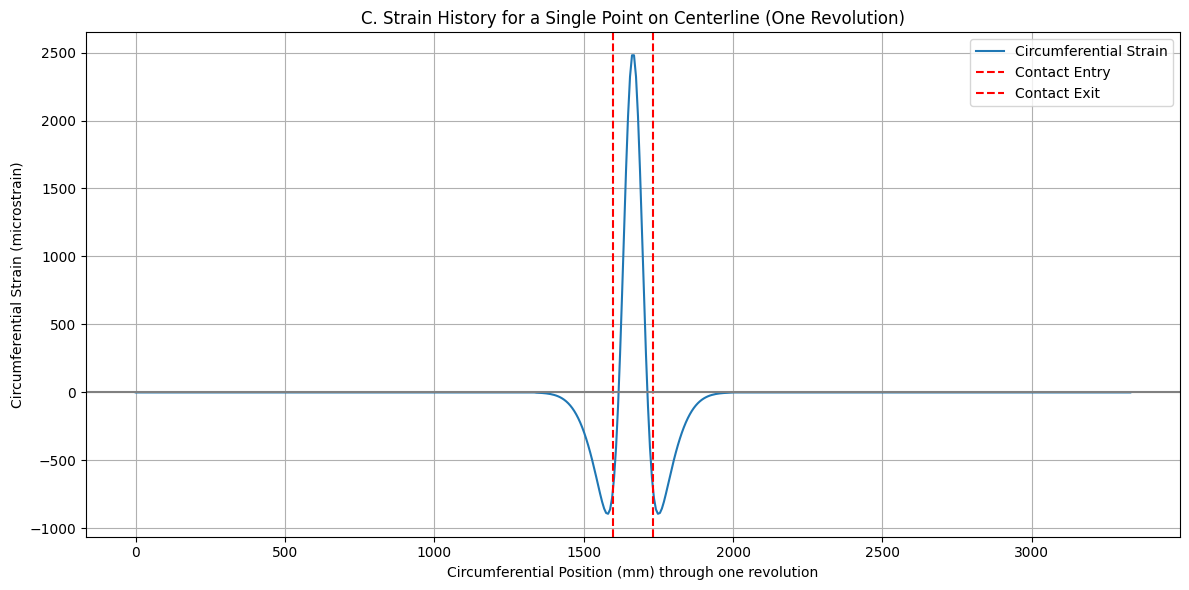

In [6]:
# --- C. Strain-History Plot for a Single Point on the Centerline --- #

# Calculate the total circumference of the tire
total_circumference = 2 * np.pi * inflated_radius  # m

# Number of points for one revolution
n_points_revolution = 500

# Angular positions over one revolution (0 to 2*pi)
# We'll map these angular positions to an 'unrolled' circumferential distance
circumferential_distances = np.linspace(0, total_circumference, n_points_revolution)

# Let's assume the contact patch is centered at total_circumference / 2 for this plot.
contact_center_circumferential = total_circumference / 2

# Define a wider 'active' region on the circumference where the strain model applies.
# This ensures we capture the pre-compression, main tension, post-compression, and then decay to zero.
# The factor (e.g., 2.5) determines how far before/after the contact patch we consider significant strain.
circumferential_influence_half_length = contact_patch_length * 2.5

active_circumferential_start = contact_center_circumferential - circumferential_influence_half_length
active_circumferential_end = contact_center_circumferential + circumferential_influence_half_length

# Create an array of relative x positions for the strain function.
# This array will contain the actual relative distance from the contact center
# for points within the influence zone, and will be used to calculate strain.
# Points outside this zone will have their strain explicitly set to zero later.
true_relative_x_positions = np.array([dist - contact_center_circumferential for dist in circumferential_distances])

# Evaluate strain for all these relative x positions at the centerline (y=0)
# The `calculate_circumferential_strain` function expects x and y as arrays for meshgrid compatibility.
x_for_history_calc = true_relative_x_positions.reshape(1, -1) # Reshape to (1, N) for broadcasting
y_for_history_calc = np.array([0.0]).reshape(-1, 1) # Single y value (0) for centerline, reshaped to (M, 1)

# Calculate the raw strain history using the model
raw_strain_history = calculate_circumferential_strain(
    x_for_history_calc,
    y_for_history_calc,
    peak_strain,
    contact_patch_length,
    tire_width
)[0, :] # Extract the 1D strain history for the centerline

# Now, apply the condition that strain is zero outside the defined active region.
# This corrects the issue where `x=0` far from contact resulted in `peak_strain`.
strain_history_centerline = np.copy(raw_strain_history) # Start with calculated values

for i, dist_on_circumference in enumerate(circumferential_distances):
    if not (active_circumferential_start <= dist_on_circumference <= active_circumferential_end):
        strain_history_centerline[i] = 0.0 # Explicitly set to zero far from contact

# Convert circumferential_distances to mm for plotting
circumferential_distances_mm = circumferential_distances * 1000

plt.figure(figsize=(12, 6))
plt.plot(circumferential_distances_mm, strain_history_centerline, label='Circumferential Strain')
plt.xlabel('Circumferential Position (mm) through one revolution')
plt.ylabel('Circumferential Strain (microstrain)')
plt.title('C. Strain History for a Single Point on Centerline (One Revolution)')
plt.grid(True)
# The contact entry/exit lines refer to the actual contact patch, not the wider influence zone.
plt.axvline(x=contact_center_circumferential * 1000 - contact_patch_length / 2 * 1000, color='r', linestyle='--', label='Contact Entry')
plt.axvline(x=contact_center_circumferential * 1000 + contact_patch_length / 2 * 1000, color='r', linestyle='--', label='Contact Exit')
plt.axhline(y=0, color='grey', linestyle='-')
plt.legend()
plt.tight_layout()
plt.show()

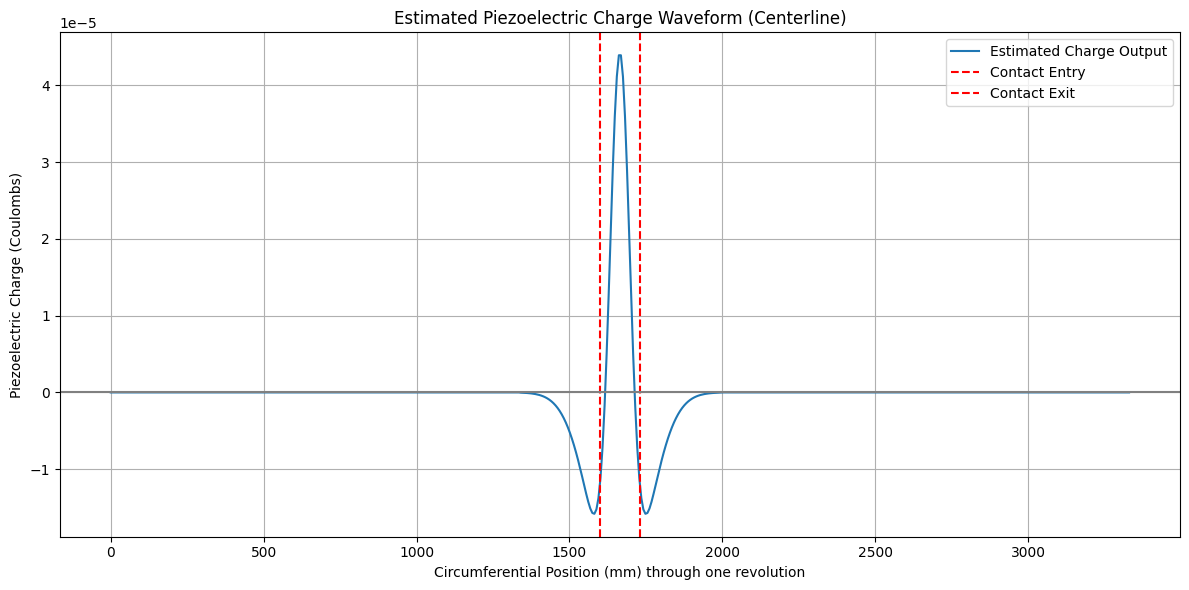

All requested outputs generated and plots updated.


In [7]:
# Re-running the Piezoelectric Charge Waveform Calculation and Plotting with the corrected strain history

# Convert microstrain to unitless strain
strain_unitless = strain_history_centerline / 1e6

# Calculate charge waveform
charge_waveform = d33 * youngs_modulus * patch_area_piezo * strain_unitless

plt.figure(figsize=(12, 6))
plt.plot(circumferential_distances_mm, charge_waveform, label='Estimated Charge Output')
plt.xlabel('Circumferential Position (mm) through one revolution')
plt.ylabel('Piezoelectric Charge (Coulombs)')
plt.title('Estimated Piezoelectric Charge Waveform (Centerline)')
plt.grid(True)
plt.axvline(x=contact_center_circumferential*1000 - contact_patch_length/2*1000, color='r', linestyle='--', label='Contact Entry')
plt.axvline(x=contact_center_circumferential*1000 + contact_patch_length/2*1000, color='r', linestyle='--', label='Contact Exit')
plt.axhline(y=0, color='grey', linestyle='-')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.legend()
plt.tight_layout()
plt.show()

print("All requested outputs generated and plots updated.")

### Estimated Piezoelectric Voltage Waveform

To convert the charge waveform to a voltage waveform, we need the capacitance of the piezoelectric patch. The capacitance (C) can be estimated using the formula:

`C = (ε_r * ε_0 * A) / t`

Where:
- `ε_r` is the relative permittivity of the piezoelectric material.
- `ε_0` is the vacuum permittivity (a physical constant).
- `A` is the patch area.
- `t` is the thickness of the piezoelectric patch.

Once `C` is known, the voltage `V` is simply:

`V = Q / C`

Estimated Piezoelectric Patch Capacitance: 9.93e-08 F


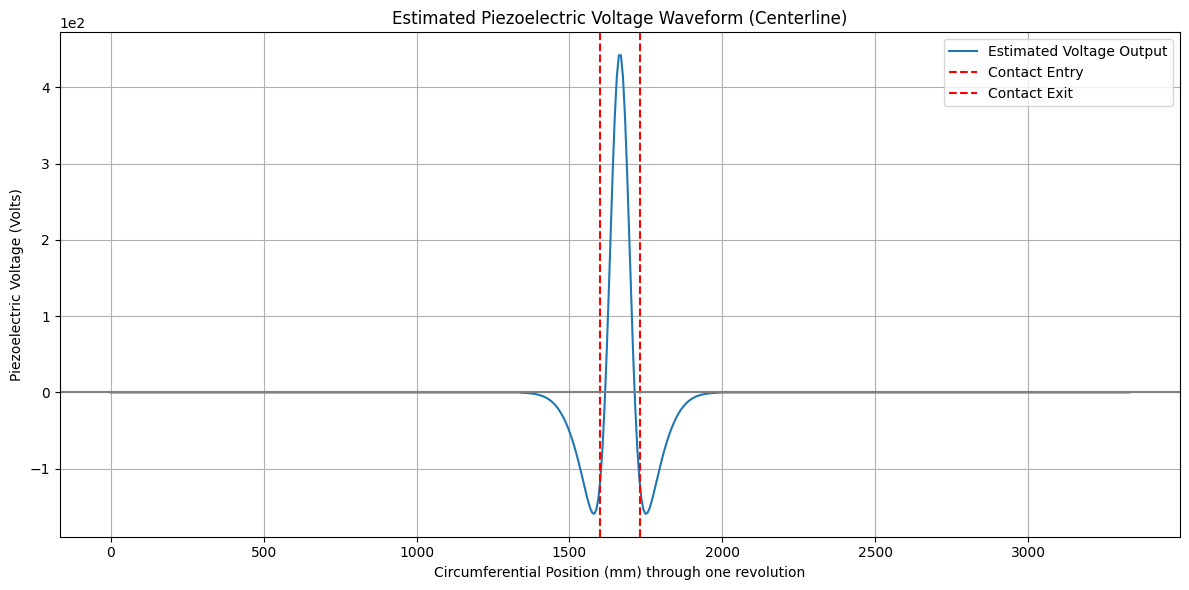

In [11]:
# --- Additional Piezoelectric Material Parameters for Voltage Calculation --- #
relative_permittivity = 1700 # Unitless (typical for PZT-5H or similar)
vacuum_permittivity = 8.854e-12 # F/m (Farads per meter)
piezo_patch_thickness = 0.2e-3 # m (0.2 mm, typical thickness for flexible piezo films)

# --- Calculate Capacitance --- #
capacitance = (relative_permittivity * vacuum_permittivity * patch_area_piezo) / piezo_patch_thickness
print(f"Estimated Piezoelectric Patch Capacitance: {capacitance:.2e} F")

# --- Calculate Voltage Waveform --- #
# V = Q / C
voltage_waveform = charge_waveform / capacitance

# --- Plot the Voltage Waveform --- #
plt.figure(figsize=(12, 6))
plt.plot(circumferential_distances_mm, voltage_waveform, label='Estimated Voltage Output')
plt.xlabel('Circumferential Position (mm) through one revolution')
plt.ylabel('Piezoelectric Voltage (Volts)')
plt.title('Estimated Piezoelectric Voltage Waveform (Centerline)')
plt.grid(True)
plt.axvline(x=contact_center_circumferential*1000 - contact_patch_length/2*1000, color='r', linestyle='--', label='Contact Entry')
plt.axvline(x=contact_center_circumferential*1000 + contact_patch_length/2*1000, color='r', linestyle='--', label='Contact Exit')
plt.axhline(y=0, color='grey', linestyle='-')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.legend()
plt.tight_layout()
plt.show()

## Graphical Representation of Multiple Parameter Effects

To graphically represent how `load` and `inflation_pressure` affect the circumferential strain, we need to establish relationships between these parameters and the `peak_strain` and `contact_patch_length` used in our `calculate_circumferential_strain` function.

We will define simplified scaling functions based on the initial default parameters. These are first-order approximations for illustrative purposes.

**Assumed Scaling Relationships:**
- **Contact Patch Length:** Tends to increase with load and decrease with inflation pressure. We'll use:
  `new_L_cp = current_L_cp * (load / current_load)^0.5 * (current_inflation_pressure / inflation_pressure)^0.5`
- **Peak Strain:** Tends to increase with load and decrease with inflation pressure. We'll use:
  `new_peak_strain = current_peak_strain * (load / current_load)^1.0 * (current_inflation_pressure / inflation_pressure)^1.0`

Vehicle speed has more complex, dynamic effects (centrifugal forces, viscoelasticity) that are harder to capture with simple static scaling, so we'll primarily demonstrate the effects of load and inflation pressure.

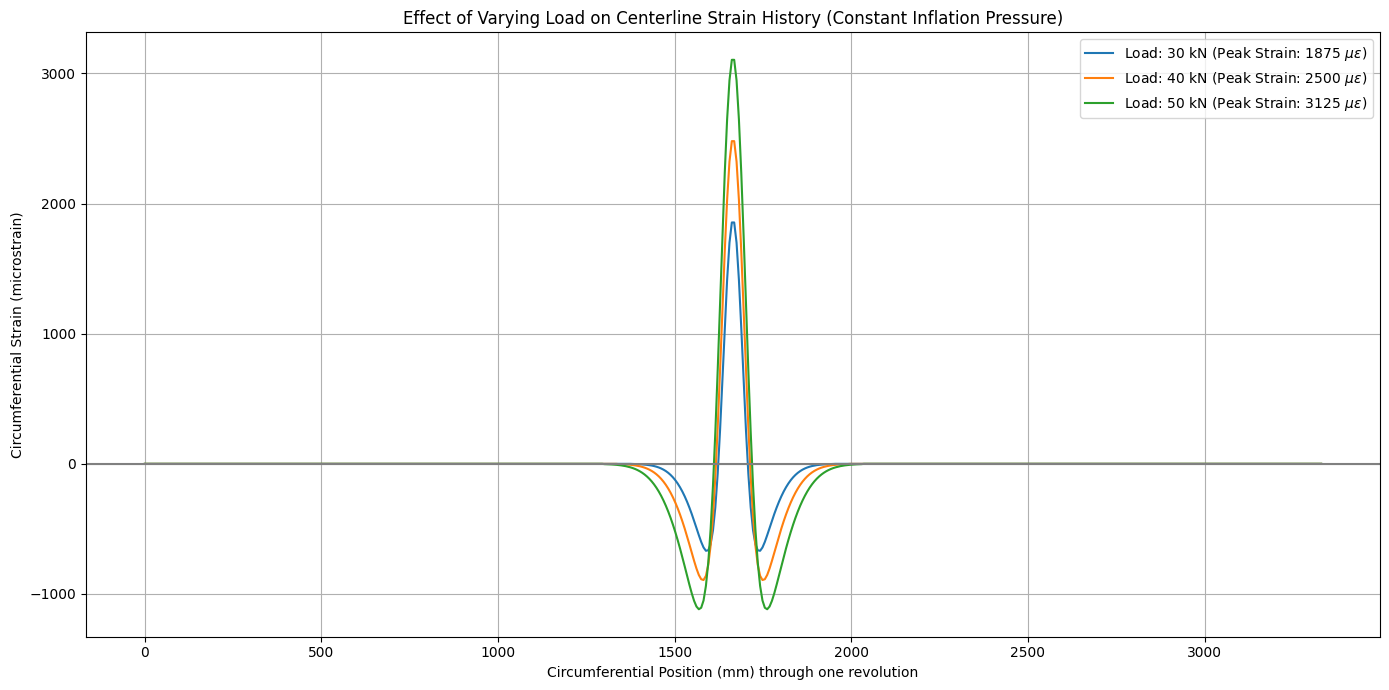

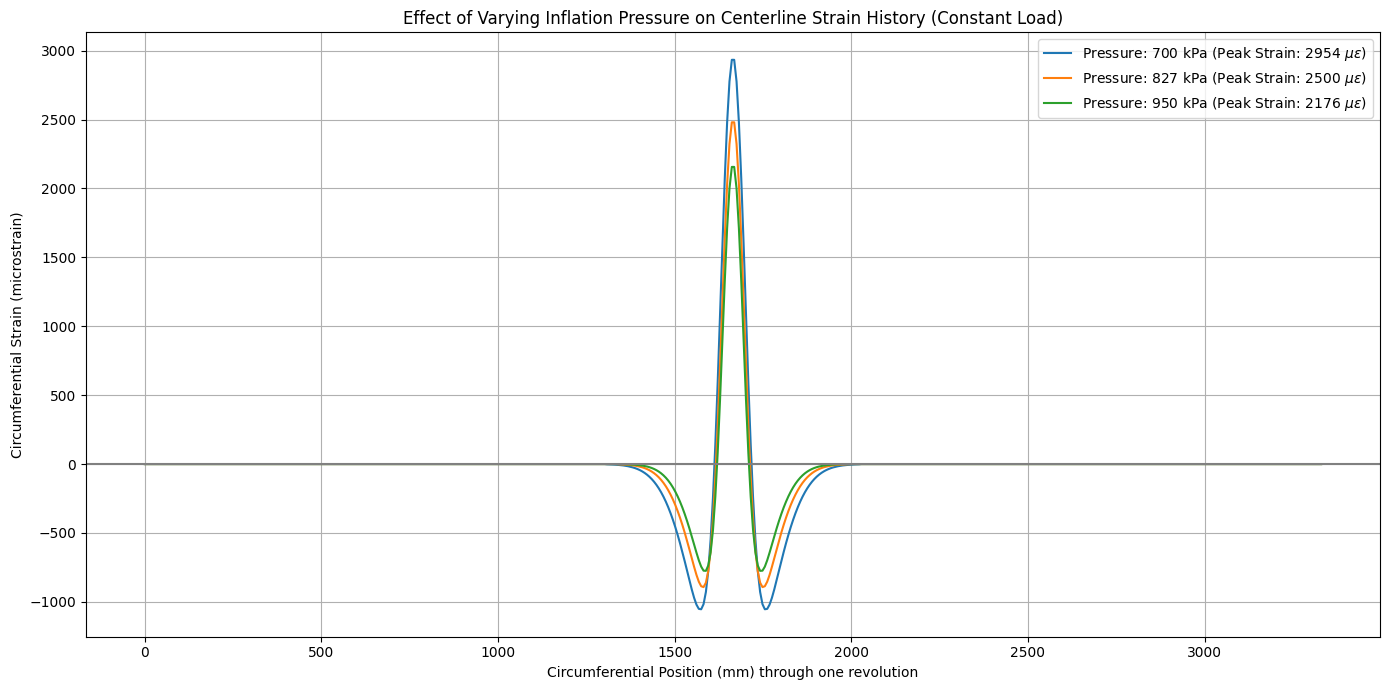

In [10]:
# --- Define Scaling Functions for Model Parameters --- #

# Reference values from initial setup
current_load = load
current_inflation_pressure = inflation_pressure
current_contact_patch_length = contact_patch_length
current_peak_strain = peak_strain

def scale_contact_patch_length(new_load, new_inflation_pressure,
                               current_load, current_inflation_pressure, current_contact_patch_length):
    """
    Scales contact patch length based on load and inflation pressure.
    Assumes a power-law relationship (approx. sqrt for load/pressure ratio).
    """
    load_factor = (new_load / current_load)**0.5
    pressure_factor = (current_inflation_pressure / new_inflation_pressure)**0.5
    return current_contact_patch_length * load_factor * pressure_factor

def scale_peak_strain(new_load, new_inflation_pressure,
                      current_load, current_inflation_pressure, current_peak_strain):
    """
    Scales peak strain based on load and inflation pressure.
    Assumes a linear-like relationship for illustrative purposes.
    """
    load_factor = (new_load / current_load)**1.0
    pressure_factor = (current_inflation_pressure / new_inflation_pressure)**1.0
    return current_peak_strain * load_factor * pressure_factor


# --- Visualize Effect of Varying Load --- #
plt.figure(figsize=(14, 7))
loads_to_test = [30000, 40000, 50000] # N
fixed_inflation_pressure = inflation_pressure # Use original inflation pressure

for test_load in loads_to_test:
    # Calculate scaled parameters
    scaled_L_cp = scale_contact_patch_length(test_load, fixed_inflation_pressure,
                                             current_load, current_inflation_pressure, current_contact_patch_length)
    scaled_peak_strain = scale_peak_strain(test_load, fixed_inflation_pressure,
                                           current_load, current_inflation_pressure, current_peak_strain)

    # Recalculate strain history with new parameters
    x_for_history_calc = true_relative_x_positions.reshape(1, -1)
    y_for_history_calc = np.array([0.0]).reshape(-1, 1)

    raw_strain_history_scaled = calculate_circumferential_strain(
        x_for_history_calc,
        y_for_history_calc,
        scaled_peak_strain,
        scaled_L_cp,
        tire_width
    )[0, :]

    strain_history_centerline_scaled = np.copy(raw_strain_history_scaled)
    for i, dist_on_circumference in enumerate(circumferential_distances):
        # Redefine active region based on new scaled_L_cp
        scaled_circumferential_influence_half_length = scaled_L_cp * 2.5
        scaled_active_circumferential_start = contact_center_circumferential - scaled_circumferential_influence_half_length
        scaled_active_circumferential_end = contact_center_circumferential + scaled_circumferential_influence_half_length

        if not (scaled_active_circumferential_start <= dist_on_circumference <= scaled_active_circumferential_end):
            strain_history_centerline_scaled[i] = 0.0

    plt.plot(circumferential_distances_mm, strain_history_centerline_scaled,
             label=f'Load: {test_load/1000:.0f} kN (Peak Strain: {scaled_peak_strain:.0f} $\\mu\\epsilon$)')

plt.xlabel('Circumferential Position (mm) through one revolution')
plt.ylabel('Circumferential Strain (microstrain)')
plt.title('Effect of Varying Load on Centerline Strain History (Constant Inflation Pressure)')
plt.grid(True)
plt.axhline(y=0, color='grey', linestyle='-')
plt.legend()
plt.tight_layout()
plt.show()


# --- Visualize Effect of Varying Inflation Pressure --- #
plt.figure(figsize=(14, 7))
pressures_to_test = [700e3, 827e3, 950e3] # Pa
fixed_load = load # Use original load

for test_pressure in pressures_to_test:
    # Calculate scaled parameters
    scaled_L_cp = scale_contact_patch_length(fixed_load, test_pressure,
                                             current_load, current_inflation_pressure, current_contact_patch_length)
    scaled_peak_strain = scale_peak_strain(fixed_load, test_pressure,
                                           current_load, current_inflation_pressure, current_peak_strain)

    # Recalculate strain history with new parameters
    x_for_history_calc = true_relative_x_positions.reshape(1, -1)
    y_for_history_calc = np.array([0.0]).reshape(-1, 1)

    raw_strain_history_scaled = calculate_circumferential_strain(
        x_for_history_calc,
        y_for_history_calc,
        scaled_peak_strain,
        scaled_L_cp,
        tire_width
    )[0, :]

    strain_history_centerline_scaled = np.copy(raw_strain_history_scaled)
    for i, dist_on_circumference in enumerate(circumferential_distances):
        # Redefine active region based on new scaled_L_cp
        scaled_circumferential_influence_half_length = scaled_L_cp * 2.5
        scaled_active_circumferential_start = contact_center_circumferential - scaled_circumferential_influence_half_length
        scaled_active_circumferential_end = contact_center_circumferential + scaled_circumferential_influence_half_length

        if not (scaled_active_circumferential_start <= dist_on_circumference <= scaled_active_circumferential_end):
            strain_history_centerline_scaled[i] = 0.0

    plt.plot(circumferential_distances_mm, strain_history_centerline_scaled,
             label=f'Pressure: {test_pressure/1000:.0f} kPa (Peak Strain: {scaled_peak_strain:.0f} $\\mu\\epsilon$)')

plt.xlabel('Circumferential Position (mm) through one revolution')
plt.ylabel('Circumferential Strain (microstrain)')
plt.title('Effect of Varying Inflation Pressure on Centerline Strain History (Constant Load)')
plt.grid(True)
plt.axhline(y=0, color='grey', linestyle='-')
plt.legend()
plt.tight_layout()
plt.show()


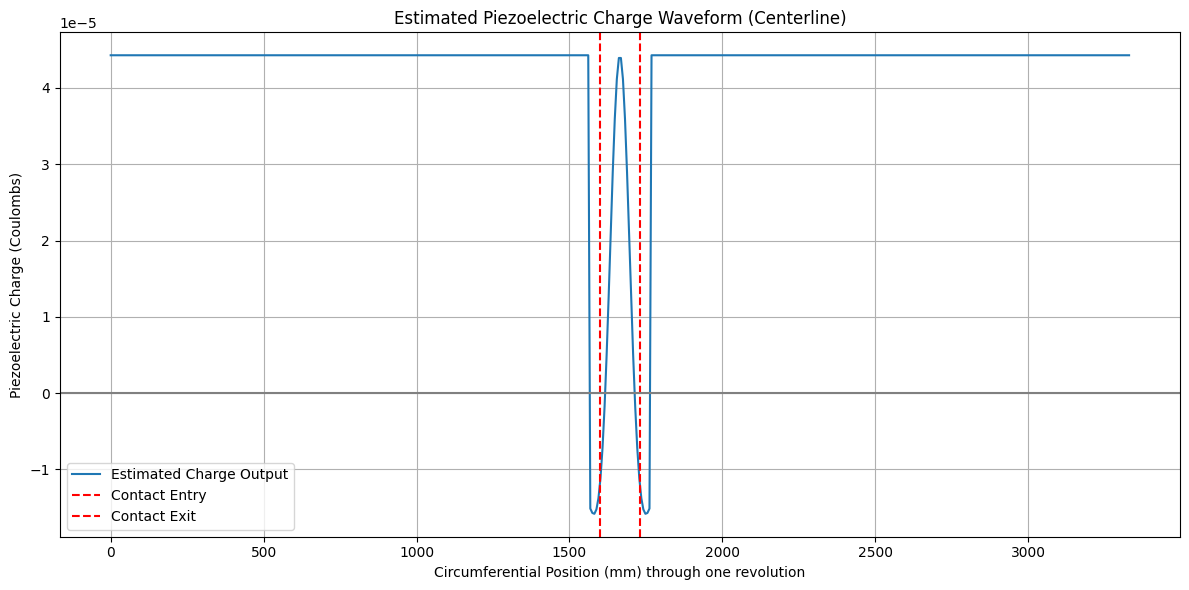

In [4]:
# --- Piezoelectric Charge Waveform Calculation and Plotting --- #

# The piezoelectric patch is assumed to be on the centerline, so we use strain_history_centerline
# Q = d33 * E * A * strain
# Strain needs to be converted from microstrain to actual strain (unitless)

# Convert microstrain to unitless strain
strain_unitless = strain_history_centerline / 1e6

# Calculate charge waveform
charge_waveform = d33 * youngs_modulus * patch_area_piezo * strain_unitless

plt.figure(figsize=(12, 6))
plt.plot(circumferential_distances_mm, charge_waveform, label='Estimated Charge Output')
plt.xlabel('Circumferential Position (mm) through one revolution')
plt.ylabel('Piezoelectric Charge (Coulombs)')
plt.title('Estimated Piezoelectric Charge Waveform (Centerline)')
plt.grid(True)
plt.axvline(x=contact_center_circumferential*1000 - contact_patch_length/2*1000, color='r', linestyle='--', label='Contact Entry')
plt.axvline(x=contact_center_circumferential*1000 + contact_patch_length/2*1000, color='r', linestyle='--', label='Contact Exit')
plt.axhline(y=0, color='grey', linestyle='-')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# --- D. Export the Strain Field as a NumPy Array --- #

# The 2D strain field calculated earlier is `strain_field_2d`.
# This array represents the circumferential strain across the contact patch (y_coords, x_coords).
# It's already a NumPy array.

# Save the array to a .npy file
output_filename = 'circumferential_strain_field.npy'
np.save(output_filename, strain_field_2d)

print(f"Strain field (2D array of microstrain values) exported to '{output_filename}'.")
print(f"Shape of exported array: {strain_field_2d.shape}")
print(f"Example values (top-left corner):\n{strain_field_2d[:5, :5]}")


Strain field (2D array of microstrain values) exported to 'circumferential_strain_field.npy'.
Shape of exported array: (100, 200)
Example values (top-left corner):
[[-317.81372225 -310.52680117 -302.90811861 -294.95336553 -286.65847456]
 [-327.90116725 -320.38295843 -312.52245799 -304.31522011 -295.75704832]
 [-338.09312157 -330.3412288  -322.23640516 -313.77406665 -304.94988637]
 [-348.37963719 -340.39189234 -332.04047866 -323.32067269 -314.22801588]
 [-358.75027659 -350.52475085 -341.92473051 -332.9453515  -323.58202253]]
